In [9]:
# 导入 Python 内置的 json 模块，用于处理 JSON 格式的数据
import json 

# 定义一个函数 fun1
def fun1():
    # 使用 with 语句打开文件，结束时自动关闭，不需要手动 f.close()
    # 'r' 表示只读模式，encoding='utf-8' 指定文件编码，防止中文乱码
    with open('city.json', 'r', encoding='utf-8') as f:
        # 读取文件的全部内容，返回一个字符串
        info = f.read()
        
    # json.loads() 将 JSON 字符串解析为 Python 字典
    info_dict = json.loads(info)
    print(info_dict['city'])
    print(info_dict['population'])
    print(info_dict['area'])

if __name__ == '__main__':
    # 调用 fun1 函数
    fun1()


北京
21540000
16410


In [2]:
# 读取 lable.txt 文件，使用 \t 分割，提取图片名称、车牌和 points
import json

def parse_label_file(file_path='lable.txt'):
    """解析 lable.txt 文件，提取图片名称、车牌号和 points 坐标"""
    records = []
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # 处理可能存在的跨行 JSON（有些记录分两行显示）
    # 先将所有行合并，再按图片名称特征分割
    content = ''.join(lines)
    # 按 train_X.jpg 模式分割
    import re
    parts = re.split(r'(?=train_\d+\.jpg )', content)
    
    for part in parts:
        part = part.strip()
        if not part:
            continue
        
        # 使用 \t 分割，如果没有 \t，则按第一个空格分割
        if '\t' in part:
            parts_split = part.split('\t', 1)
        else:
            # 按第一个空格分割
            idx = part.index(' ')
            parts_split = [part[:idx], part[idx+1:]]
        
        if len(parts_split) < 2:
            continue
        
        img_name = parts_split[0]
        json_str = parts_split[1]
        
        try:
            data_list = json.loads(json_str)
            for item in data_list:
                transcription = item['transcription']
                points = item['points']
                records.append({
                    'image': img_name,
                    'license_plate': transcription,
                    'points': points
                })
        except json.JSONDecodeError as e:
            print(f"解析 JSON 失败: {e}")
            print(f"问题数据: {json_str}")
    
    return records

# 执行解析
result = parse_label_file()

# 打印结果
print(f"共解析出 {len(result)} 条记录：\n")
for r in result:
    print(f"图片: {r['image']}")
    print(f"车牌: {r['license_plate']}")
    print(f"坐标: {r['points']}")
    print("-" * 50)


共解析出 10 条记录：

图片: train_0.jpg
车牌: 桂AL6S50
坐标: [[86, 238], [181, 238], [181, 261], [86, 261]]
--------------------------------------------------
图片: train_1.jpg
车牌: 鄂A9L638
坐标: [[178, 1008], [425, 1008], [425, 1099], [178, 1099]]
--------------------------------------------------
图片: train_2.jpg
车牌: 桂B0W532
坐标: [[18, 430], [145, 430], [145, 505], [18, 505]]
--------------------------------------------------
图片: train_3.jpg
车牌: 桂AH15M6
坐标: [[180, 759], [407, 759], [407, 822], [180, 822]]
--------------------------------------------------
图片: train_4.jpg
车牌: 吉AU78M0
坐标: [[128, 653], [415, 653], [415, 748], [128, 748]]
--------------------------------------------------
图片: train_5.jpg
车牌: 桂AY1916
坐标: [[330, 820], [529, 820], [529, 883], [330, 883]]
--------------------------------------------------
图片: train_6.jpg
车牌: 桂A052HT
坐标: [[138, 537], [385, 537], [385, 640], [138, 640]]
--------------------------------------------------
图片: train_7.jpg
车牌: 桂NJB585
坐标: [[0, 532], [203, 532], [203, 6

XML标注文件基础介绍

- XML语言定义：XML即可扩展标记语言，结构和HTML类似，都是成对的尖括号标签，但XML标签名可以自定义，设计宗旨是传输和存储数据，HTML的宗旨是展示数据。
- XML标签规则：标签必须成对出现，特殊无内容标签可以单标签但必须带结束符，标签可以定义属性，必须正确嵌套才能使用。
- 标注文件结构：精灵助手标注后导出Pascal VOC格式XML，根标签为annotation，需要提取的信息包括size标签下的图片宽高，以及每个object标签下的目标名称、 bounding box坐标。

XML标注文件解析代码实操

- 模块导入方式：需要导入`xml.etree.ElementTree`模块，通常取别名为et，这是本次课程中导入路径最长的模块，要求学员重点记忆。
- 文件加载与根标签获取：使用`et.parse()`方法加载XML文件得到tree对象，再调用`tree.getroot()`方法获取根标签对象。
- 三种标签取值方法：第一种是逐级调用find方法找到对应标签后取text属性；第二种是用斜杠拼接路径在find中直接查找；第三种是直接使用findtext方法获取标签文本内容，第三种写法最简单最常用。
- 多目标处理方式：使用`findall`方法找到所有object标签得到列表，对列表循环逐个处理，每个object从当前对象开始查找name和坐标信息，不需要再从根标签查找。

In [5]:
# ============================================================
# 解析 XML 标注文件（Pascal VOC 格式）
# 文件来源：精灵标注助手导出的猫狗数据集标注文件
# XML 结构类似 HTML，但标签名可以自定义，用来存储结构化数据
# ============================================================

# xml.etree.ElementTree 是 Python 自带的 XML 解析模块
# 不需要额外安装，导入即可使用
# 为了书写方便，给它取个别名 ET（就像 import pandas as pd 一样）
import xml.etree.ElementTree as ET


def parse_voc_xml(file_path='Abyssinian_1.xml'):
    """
    解析 Pascal VOC 格式的 XML 标注文件

    参数:
        file_path: XML 文件的路径，默认当前目录下的 Abyssinian_1.xml
    
    返回值:
        无（直接将结果打印输出）
    """

    # --------------------------------------------------------
    # 第一步：加载 XML 文件
    # --------------------------------------------------------
    # ET.parse() 读取 XML 文件，返回一个"树"对象（tree）
    # 可以把这个 tree 想象成一棵倒挂的树，根在最上面，枝叶往下展开
    tree = ET.parse(file_path)

    # tree.getroot() 获取根标签
    # 相当于拿到了整棵树的根节点，从这个根节点出发可以找到所有子标签
    # 在我们的 XML 中，根标签就是 <annotation>
    root = tree.getroot()

    # --------------------------------------------------------
    # 第二步：提取图片基本信息
    # --------------------------------------------------------
    # .find('标签名') 方法：在当前标签下查找第一个匹配的子标签
    # 就像在文件夹里找第一个名字匹配的文件
    # .text 属性：获取标签对之间的文本内容
    # 例如 <folder>OXIIIT</folder> 的 .text 就是 "OXIIIT"
    folder = root.find('folder').text    # 从 <annotation> 下找 <folder>，取文本内容
    filename = root.find('filename').text  # 从 <annotation> 下找 <filename>，取文本内容

    # --------------------------------------------------------
    # 第三步：提取图片尺寸信息
    # --------------------------------------------------------
    # <size> 标签下面还有三个子标签：<width>、<height>、<depth>
    # 先找到 <size> 标签，再分别从它下面找宽、高、通道数
    size = root.find('size')                      # 先定位到 <size> 标签
    width = size.find('width').text                # 再从 <size> 下找 <width>，取文本
    height = size.find('height').text              # 再从 <size> 下找 <height>，取文本
    depth = size.find('depth').text                # 再从 <size> 下找 <depth>，取文本
    # 注意：这里 width、height、depth 都是字符串类型（str），不是数字

    # 打印图片基本信息
    # f-string（格式化字符串）：在字符串前加 f，就可以用 {} 把变量嵌入到字符串中
    # \n 是换行符，让输出结果更清晰
    print(f"文件夹: {folder}")
    print(f"文件名: {filename}")
    print(f"图像尺寸: {width} x {height} x {depth}\n")

    # --------------------------------------------------------
    # 第四步：提取所有标注目标的信息
    # --------------------------------------------------------
    # .findall('标签名') 方法：找到当前标签下所有匹配的子标签，返回一个列表
    # 一张图片里可能有多只猫/狗，所以有多个 <object> 标签
    # enumerate(列表, start=1) 可以把列表变成 (序号, 元素) 的形式
    # 例如 enumerate(['a','b'], 1) 会依次给出 (1, 'a') 和 (2, 'b')
    for i, obj in enumerate(root.findall('object'), 1):
        # 从当前 object 标签下提取各类信息
        name = obj.find('name').text               # 目标类别名，如 "cat" 或 "dog"
        pose = obj.find('pose').text               # 拍摄姿态，如 "Frontal"（正面）
        truncated = obj.find('truncated').text      # 是否被截断（0=否，1=是）
        occluded = obj.find('occluded').text        # 是否被遮挡（0=否，1=是）
        difficult = obj.find('difficult').text      # 是否为难例（0=否，1=是）

        # --------------------------------------------------------
        # 第五步：提取边界框（bounding box）坐标
        # --------------------------------------------------------
        # <bndbox> 标签包含四个子标签，定义了一个矩形框
        # (xmin, ymin) = 矩形左上角的坐标
        # (xmax, ymax) = 矩形右下角的坐标
        # 这个矩形框就是标注出的猫/狗在图片中的位置
        bndbox = obj.find('bndbox')                 # 先定位到 <bndbox> 标签
        xmin = bndbox.find('xmin').text             # 框的左边界 x 坐标（字符串）
        ymin = bndbox.find('ymin').text             # 框的上边界 y 坐标（字符串）
        xmax = bndbox.find('xmax').text             # 框的右边界 x 坐标（字符串）
        ymax = bndbox.find('ymax').text             # 框的下边界 y 坐标（字符串）

        # 打印每个目标的信息
        # int() 函数：把字符串转成整数，方便做数学运算
        # 这里计算框的宽度 = 右边 - 左边，高度 = 下边 - 上边
        print(f"目标 {i}:")
        print(f"  类别: {name}")
        print(f"  姿态: {pose}")
        print(f"  截断: {truncated}")                # 0=完整可见，1=图像边缘被截断
        print(f"  遮挡: {occluded}")                 # 0=无遮挡，1=有遮挡
        print(f"  难例: {difficult}")                # 0=普通，1=难以辨认的困难样本
        print(f"  边界框: ({xmin}, {ymin}) -> ({xmax}, {ymax})")
        print(f"  框宽高: {int(xmax)-int(xmin)} x {int(ymax)-int(ymin)}")


# --------------------------------------------------------
# 程序入口：只有直接运行此脚本时才执行下面的代码
# 如果作为模块被 import 到其他文件，则不会执行
# --------------------------------------------------------
if __name__ == '__main__':
    # 调用上面定义的函数，开始解析 XML 文件
    parse_voc_xml()


文件夹: OXIIIT
文件名: Abyssinian_1.jpg
图像尺寸: 600 x 400 x 3

目标 1:
  类别: cat
  姿态: Frontal
  截断: 0
  遮挡: 0
  难例: 0
  边界框: (333, 72) -> (425, 158)
  框宽高: 92 x 86


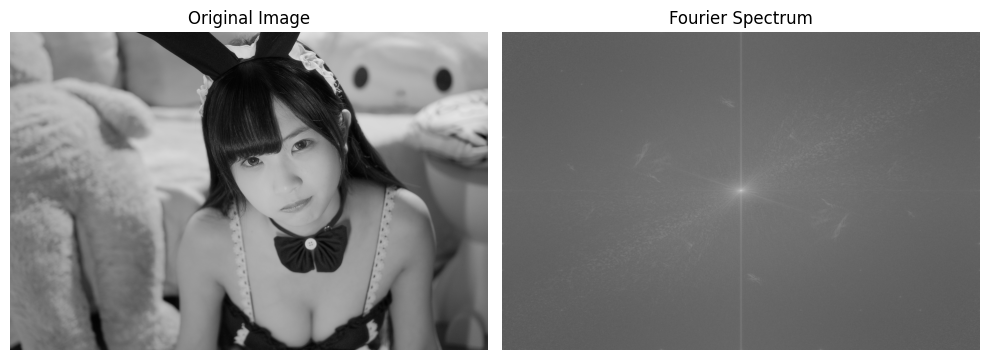

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图片（灰度图）
img = cv2.imread("01.jpg", cv2.IMREAD_GRAYSCALE)

# 傅里叶变换
f = np.fft.fft2(img)

# 将低频移动到频谱中心
fshift = np.fft.fftshift(f)

# 计算频谱幅值
magnitude_spectrum = np.abs(fshift)

# 对数变换，增强显示效果
magnitude_spectrum = np.log(magnitude_spectrum + 1)

# 显示结果
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Fourier Spectrum")
plt.axis("off")

plt.tight_layout()
plt.show()